### 第14章 模板匹配
- 模板匹配是指在图像A内寻找与图像B最相似的部分，图像A称为输入图像，图像B称为模板图像。操作方法是将图像B在图像A上滑动，遍历所有像素完成匹配
- 函数 `result = cv2.matchTemplate(image, templ, method[, mask])` 实现模板匹配，其中
    - `image` 为原始图像，必须是8位位图或32位浮点型图像
    - `templ` 为模板图像，尺寸必须小于或等于原始图像，并且类型与原始图像相同
    - `method` 为匹配方法，有 6 种可能的值 (分别对应数值0~5): 
        - `cv2.TM_SQDIFF` 以方差进行匹配。若完全匹配，则结果为零
        - `cv2.TM_SQDIFF_NORMED` 标准（归一化）平方差匹配
        - `cv2.TM_CCORR` 相关匹配，模板图像与输入图像相乘，乘积越大，表示匹配程度越高；若乘积为0，则匹配效果最差
        - `cv2.TM_CCORR_NORMED` 标准（归一化）相关匹配
        - `cv2.TM_CCOEFF` 相关系数匹配，模板图像与其均值的相对值，和输入图像与其均值的相对值进行匹配。1表示完美匹配，即完全正相关，模板和子区域的像素值变化趋势一致；-1表示完全不匹配，即完全负相关，即模板和子区域的像素值变化趋势相反；0表示没有相关性
        - `cv2.TM_CCOEFF_NORMED` 标准（归一化）相关系数匹配
    - `mask` 为模板图像掩膜，必须和templ具有相同的大小。若只有一个通道，则作用于所有的通道计算。如果数据类型是 `CV_8U`，则掩膜为二进制掩码，即所有非零值均视为1；如果数据类型是 `CV_32F`，则掩膜作为权重使用
    - `result` 是由每个位置的比较结果组合构成的单通道32位集合
    - 如果输入图像尺寸是 $ W \times H $，模板尺寸是 $ w \times h $，则返回值大小为 $ (W-w+1) \times (H-h+1) $ 

- `minVal, maxVal, minLoc, maxLoc = cv2.minMaxLoc(src[, mask])` 查找最值（极值）及其所在的位置，其中
    - `src` 为单通道数组
    - `minVal`, `maxVal` 分别为返回的最小值和最大值，若没有最小/最大值，则返回 `NULL` (空值)
    - `minLoc`, `maxLoc` 分别为最小值和最大值的位置，若没有最小/最大值，则为 `NULL`
- `Img = cv2.rectangle(img, pt1, pt2, color[, thickness])` 通过模板匹配的矩形对角线位置标记矩形，其中
    - `img` 表示要标记的目标图像
    - `pt1`, `pt2` 分别是矩形的两个对角顶点
    - `color` 是要绘制矩形的颜色或灰度级（灰度图像）
    - `thickness` 是矩形边线的宽度

th = 40 tw = 200
img.shape = (512, 512)
result.shape = (473, 313)


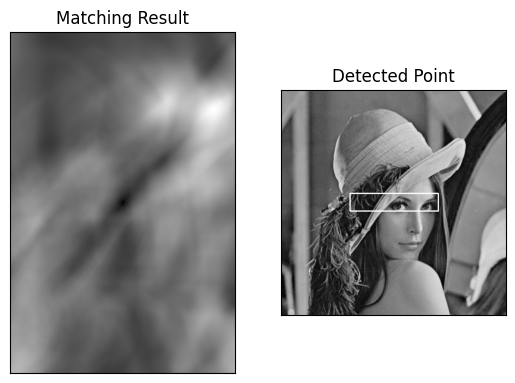

In [ ]:
# 利用 cv2.TM_SQDIFF 进行模板匹配
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('lena512g.bmp', cv2.IMREAD_GRAYSCALE)
template = cv2.imread('temp.bmp', cv2.IMREAD_GRAYSCALE)
th, tw = template.shape[::]     # 返回模板的高度和宽度
print("th =", th, "tw =", tw)
print("img.shape =", img.shape)
print("result.shape =", result.shape)

result = cv2.matchTemplate(img, template, cv2.TM_SQDIFF)
minVal, maxVal, minLoc, maxLoc = cv2.minMaxLoc(result)
topLeft = minLoc
bottomRight = (topLeft[0] + tw, topLeft[1] + th)
cv2.rectangle(img, topLeft, bottomRight, 255, 2)

plt.subplot(121)
plt.imshow(result, cmap = 'gray')
plt.title('Matching Result')
plt.xticks([])  # 轴上的刻度位置和刻度标签都设为空，结果是 x 轴上不显示任何刻度
plt.yticks([])  # 轴上的刻度位置和刻度标签都设为空，结果是 y 轴上不显示任何刻度
plt.subplot(122)
plt.imshow(img,cmap = 'gray')
plt.title('Detected Point')
plt.xticks([])
plt.yticks([])
plt.show()

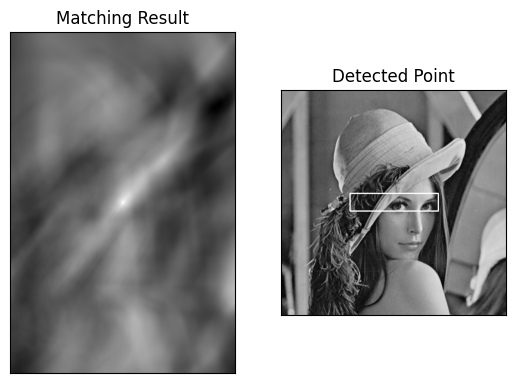

In [ ]:
# 利用 cv2.TM_CCOEFF 进行模板匹配
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread("lena512g.bmp", cv2.IMREAD_GRAYSCALE)
template = cv2.imread("temp.bmp", cv2.IMREAD_GRAYSCALE)
tw, th = template.shape[::-1]  # # 返回模板的宽度和高度，与上文不同
result = cv2.matchTemplate(img, template, cv2.TM_CCOEFF)
minVal, maxVal, minLoc, maxLoc = cv2.minMaxLoc(result)
topLeft = maxLoc
bottomRight = (topLeft[0] + tw, topLeft[1] + th)
cv2.rectangle(img, topLeft, bottomRight, 255, 2)

plt.subplot(121)
plt.imshow(result, cmap="gray")
plt.title("Matching Result")
plt.xticks([])
plt.yticks([])

plt.subplot(122)
plt.imshow(img, cmap="gray")
plt.title("Detected Point")
plt.xticks([])
plt.yticks([])
plt.show()

#### 14.2 多模板匹配
##### 1. 获取匹配位置
- `numpy.where()` 能够获取模板匹配位置的集合：
    - 当输入是一维数组时，返回值是一维数组，返回的是匹配值的位置索引
    - 当输入是二维数组时，返回二维数组，元素分别是匹配值的行、列位置索引
##### 2. 循环
- 在获取匹配值的索引集合后，可以用循环语句遍历所有匹配的位置
    ```python
        for i in 匹配位置集合
            标记匹配位置
    ``` 
- 函数 `zip()` 用可迭代的对象作为参数，将对象中对应的元素打包成一个个元组，然后返回由这些元素组成的列表
    ```python
        for i in zip(*模板匹配索引集合)
            标记处理
    ``` 

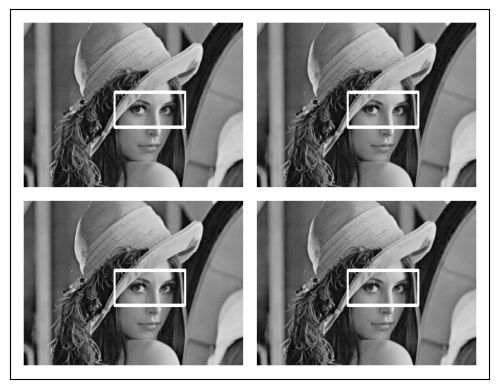

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread("lena4.bmp", cv2.IMREAD_GRAYSCALE)
template = cv2.imread("lena4Temp.bmp", cv2.IMREAD_GRAYSCALE)
w, h = template.shape[::-1]
res = cv2.matchTemplate(img, template, cv2.TM_CCOEFF_NORMED)
threshold = 0.9     
loc = np.where(res >= threshold)

# 存在多个匹配结果大于阈值0.9，所以最终矩形宽度远远大于1
for pt in zip(*loc[::-1]):
    cv2.rectangle(img, pt, (pt[0] + w, pt[1] + h), 255, 1)
plt.imshow(img, cmap="gray")
plt.xticks([])
plt.yticks([])
plt.show()